In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(r"C:/Users/manit/ai-engineer-journey/pandas-isro/ISRO Satellite Dataset.csv")

# First look
print(df.shape)
print(df.columns.tolist())
df.head()

(46, 30)
['Unnamed: 0', 'Satellite ID(Fake)', 'Name of Satellite, Alternate Names', 'Current Official Name of Satellite', 'Country/Org of UN Registry', 'Country of Operator/Owner', 'Operator/Owner', 'Users', 'Purpose', 'Detailed Purpose', 'Class of Orbit', 'Type of Orbit', 'Longitude of GEO (degrees)', 'Perigee (km)', 'Apogee (km)', 'Eccentricity', 'Inclination (degrees)', 'Period (minutes)', 'Launch Mass (kg.)', 'Dry Mass (kg.)', 'Power (watts)', 'Date of Launch', 'Expected Lifetime (yrs.)', 'Contractor', 'Country of Contractor', 'Launch Site', 'Launch Vehicle', 'COSPAR Number', 'NORAD Number', 'Comments']


,Unnamed: 0,Satellite ID(Fake),"Name of Satellite, Alternate Names",Current Official Name of Satellite,Country/Org of UN Registry,Country of Operator/Owner,Operator/Owner,Users,Purpose,Detailed Purpose,...,Power (watts),Date of Launch,Expected Lifetime (yrs.),Contractor,Country of Contractor,Launch Site,Launch Vehicle,COSPAR Number,NORAD Number,Comments
0,0,1,CartoSat 1 (IRS P5),CartoSat 1,India,India,Indian Space Research Organization (ISRO),Government,Earth Observation,Optical Imaging,...,1100.0,2005-05-05,6.0,Indian Space Research Organization (ISRO),India,Satish Dhawan Space Centre,PSLV C6,2005-017A,28649.0,"Remote sensing and mapping, land use, forest c..."
1,1,2,"CartoSat 2 (IRS P7, CartoSat 2AT)",CartoSat 2,India,India,Indian Space Research Organization (ISRO),Government,Earth Observation,Optical Imaging,...,NaN,2007-01-10,5.0,Indian Space Research Organization (ISRO),India,Satish Dhawan Space Centre,PSLV C7,2007-001B,29710.0,Remote sensing and mapping; panchromatic image...
2,2,3,CartoSat 2A,CartoSat 2A,India,India,Indian Space Research Organization (ISRO),Military,Earth Observation,Optical Imaging,...,NaN,2008-04-28,5.0,Indian Space Research Organization (ISRO),India,Satish Dhawan Space Centre,PSLV C9,2008-021A,32783.0,Military version of CartoSat 2; dedicated sate...
3,3,4,CartoSat 2B,CartoSat 2B,India,India,Indian Space Research Organization (ISRO),Government,Earth Observation,Optical Imaging,...,NaN,2010-07-12,5.0,Indian Space Research Organization (ISRO),India,Satish Dhawan Space Centre,PSLV,2010-035A,36795.0,"Resource mapping, urban planning, transportati..."
4,4,5,CartoSat 2C,CartoSat 2C,India,India,Indian Space Research Organization (ISRO),Government,Earth Observation,Optical Imaging,...,NaN,2016-06-22,5.0,Indian Space Research Organization (ISRO),India,Satish Dhawan Space Centre,PSLV XL,2016-040A,41599.0,Lower orbit for military application.


In [3]:
# Check for missing data 
print (df.isnull().sum())

Unnamed: 0                             0
Satellite ID(Fake)                     0
Name of Satellite, Alternate Names     0
Current Official Name of Satellite     0
Country/Org of UN Registry             0
Country of Operator/Owner              0
Operator/Owner                         0
Users                                  0
Purpose                                0
Detailed Purpose                      27
Class of Orbit                         0
Type of Orbit                         27
Longitude of GEO (degrees)             0
Perigee (km)                           0
Apogee (km)                            0
Eccentricity                           0
Inclination (degrees)                  0
Period (minutes)                       0
Launch Mass (kg.)                      0
Dry Mass (kg.)                        32
Power (watts)                         31
Date of Launch                         0
Expected Lifetime (yrs.)               6
Contractor                             0
Country of Contr

In [4]:
# Basic stats
df.describe()

,Unnamed: 0,Satellite ID(Fake),Longitude of GEO (degrees),Perigee (km),Apogee (km),Eccentricity,Inclination (degrees),Period (minutes),Launch Mass (kg.),Dry Mass (kg.),Power (watts),Expected Lifetime (yrs.),NORAD Number
count,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000,14.000000,15.000000,40.000000,46.000000
mean,22.500000,23.500000,45.413261,21313.695652,21360.282609,0.000956,43.896522,882.665217,1685.834783,861.428571,2250.666667,9.512500,40104.891304
std,13.422618,13.422618,42.068811,17587.078122,17612.523798,0.000806,46.499453,667.038030,1261.162819,385.521368,1452.625538,4.274983,4393.647147
min,0.000000,1.000000,0.000000,327.000000,347.000000,0.000000,0.000000,91.340000,5.000000,559.000000,1100.000000,0.500000,28051.000000
25%,11.250000,12.250000,0.000000,626.000000,643.500000,0.000273,0.100000,97.175000,712.000000,598.000000,1600.000000,5.000000,39203.250000
50%,22.500000,23.500000,55.000000,35699.500000,35795.000000,0.000792,27.595000,1436.030000,1425.000000,606.000000,1600.000000,11.000000,41534.000000
75%,33.750000,34.750000,82.375000,35775.000000,35815.750000,0.001493,97.500000,1436.100000,2452.000000,1246.250000,2330.000000,12.000000,42803.000000
max,45.000000,46.000000,129.500000,37782.000000,37807.000000,0.003052,98.800000,1437.700000,5854.000000,1493.000000,6250.000000,15.000000,47256.000000


Purpose
Earth Observation                  18
Communications                     16
Navigation/Regional Positioning     8
Technology Development              2
Communications/Navigation           1
Space Science                       1
Name: count, dtype: int64


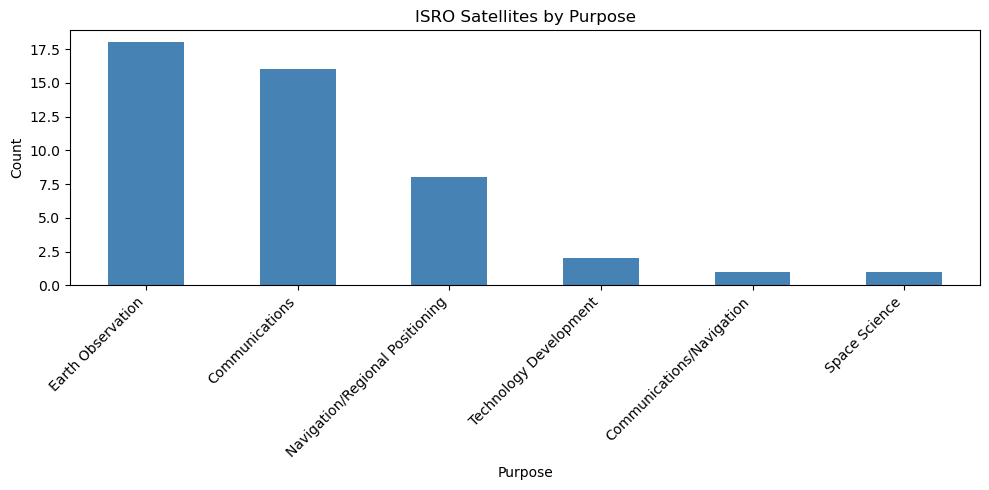

In [5]:
# Satellites by purpose
purpose_counts = df['Purpose'].value_counts()
print(purpose_counts)

# Plot
plt.figure(figsize=(10,5))
purpose_counts.plot(kind='bar', color='steelblue')
plt.title('ISRO Satellites by Purpose')
plt.xlabel('Purpose')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

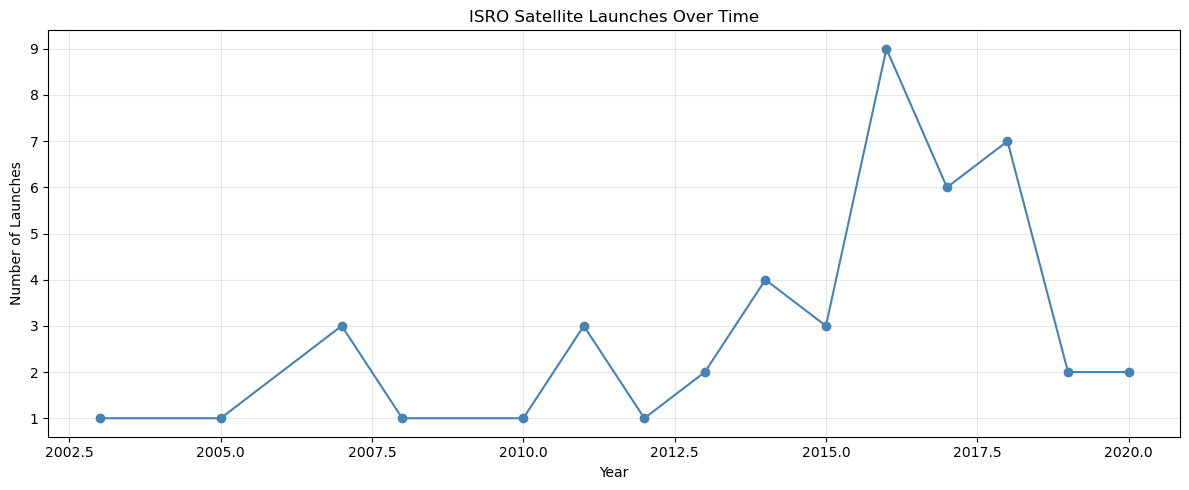

In [6]:
# Convert date column
df['Date of Launch'] = pd.to_datetime(df['Date of Launch'])
df['Launch Year'] = df['Date of Launch'].dt.year

# Satellites launched per year
launches_per_year = df['Launch Year'].value_counts().sort_index()

plt.figure(figsize=(12,5))
launches_per_year.plot(kind='line', marker='o', color='steelblue')
plt.title('ISRO Satellite Launches Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Launches')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

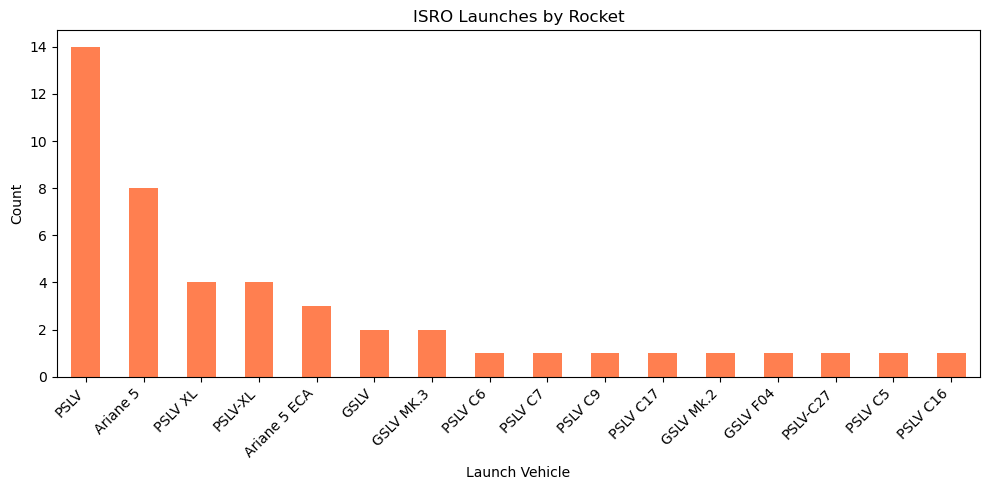

In [7]:
# Which rockets did ISRO use most?
vehicle_counts = df['Launch Vehicle'].value_counts()

plt.figure(figsize=(10,5))
vehicle_counts.plot(kind='bar', color='coral')
plt.title('ISRO Launches by Rocket')
plt.xlabel('Launch Vehicle')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

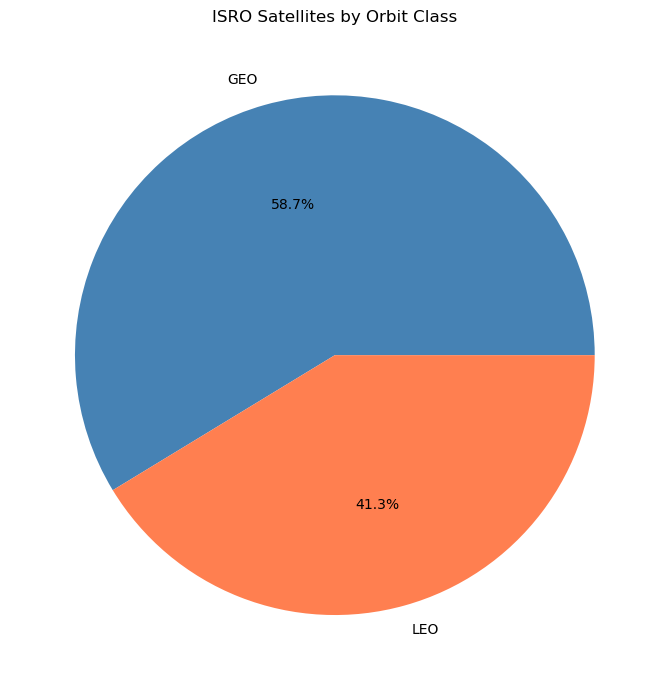

In [8]:
# Class of orbit
orbit_counts = df['Class of Orbit'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(orbit_counts, labels=orbit_counts.index, autopct='%1.1f%%', colors=['steelblue','coral','green','orange'])
plt.title('ISRO Satellites by Orbit Class')
plt.tight_layout()
plt.show()

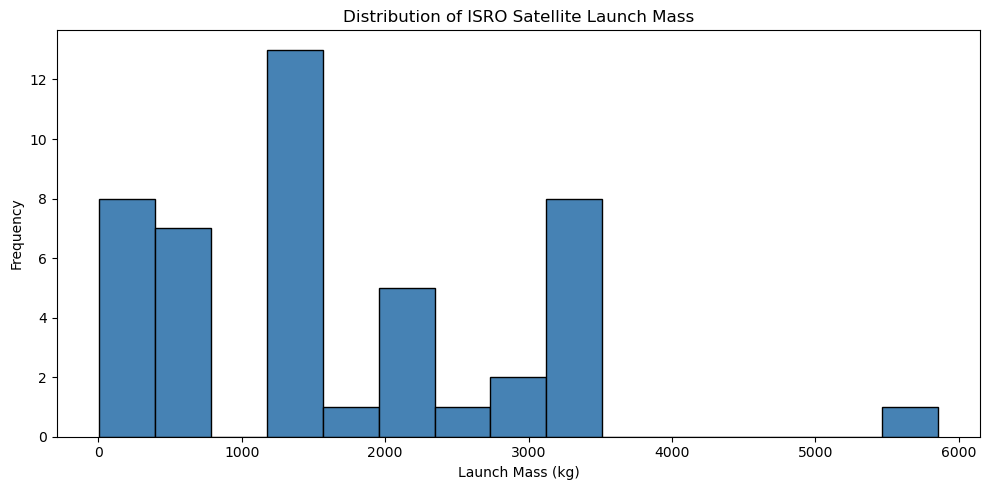

In [9]:
# Clean the mass column and plot
df['Launch Mass (kg.)'] = pd.to_numeric(df['Launch Mass (kg.)'], errors='coerce')

plt.figure(figsize=(10,5))
df['Launch Mass (kg.)'].dropna().plot(kind='hist', bins=15, color='steelblue', edgecolor='black')
plt.title('Distribution of ISRO Satellite Launch Mass')
plt.xlabel('Launch Mass (kg)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

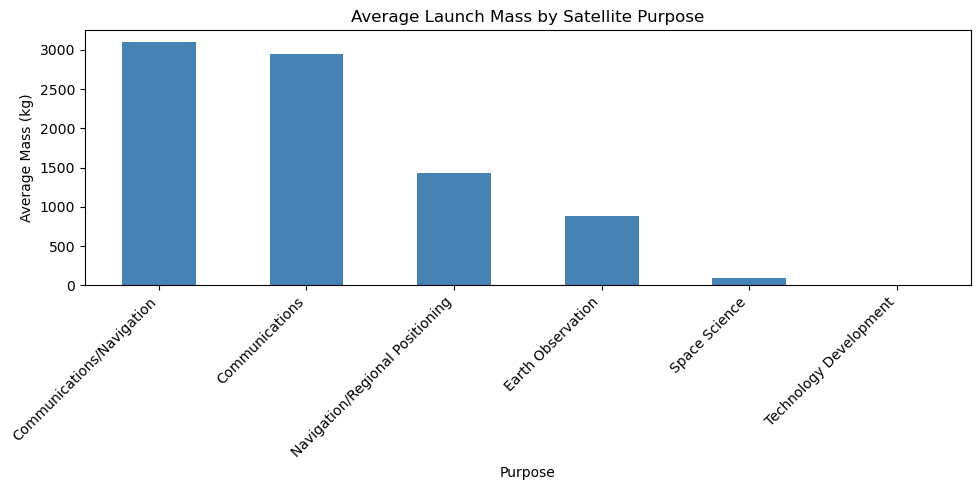

Purpose
Communications/Navigation          3093.000000
Communications                     2941.812500
Navigation/Regional Positioning    1425.875000
Earth Observation                   882.022222
Space Science                        92.000000
Technology Development                5.500000
Name: Launch Mass (kg.), dtype: float64


In [10]:
# Average launch mass by purpose
avg_mass_by_purpose = df.groupby('Purpose')['Launch Mass (kg.)'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
avg_mass_by_purpose.plot(kind='bar', color='steelblue')
plt.title('Average Launch Mass by Satellite Purpose')
plt.xlabel('Purpose')
plt.ylabel('Average Mass (kg)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(avg_mass_by_purpose)

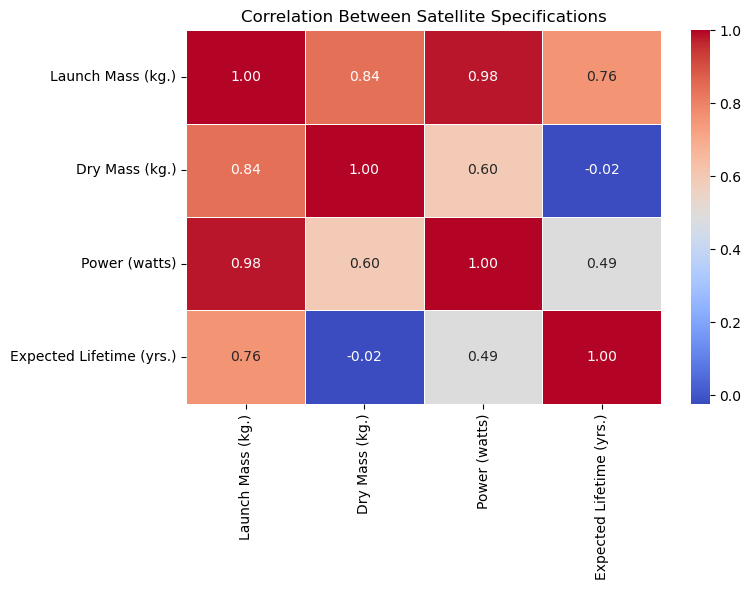

In [11]:
# Correlation between numerical columns
numerical_cols = ['Launch Mass (kg.)', 'Dry Mass (kg.)', 'Power (watts)', 'Expected Lifetime (yrs.)']

df_numeric = df[numerical_cols].apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(8,6))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Between Satellite Specifications')
plt.tight_layout()
plt.show()

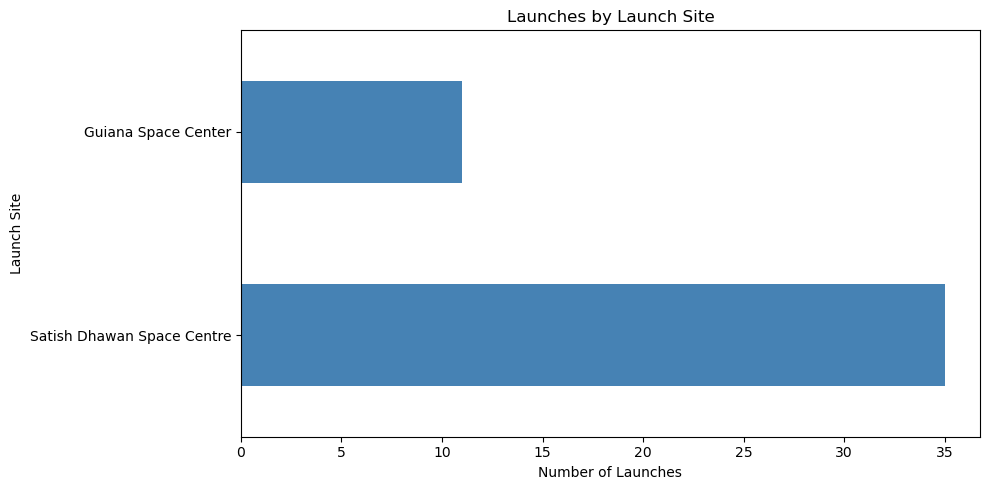

In [12]:
# Which launch sites were used most?
site_counts = df['Launch Site'].value_counts()

plt.figure(figsize=(10,5))
site_counts.plot(kind='barh', color='steelblue')
plt.title('Launches by Launch Site')
plt.xlabel('Number of Launches')
plt.tight_layout()
plt.show()

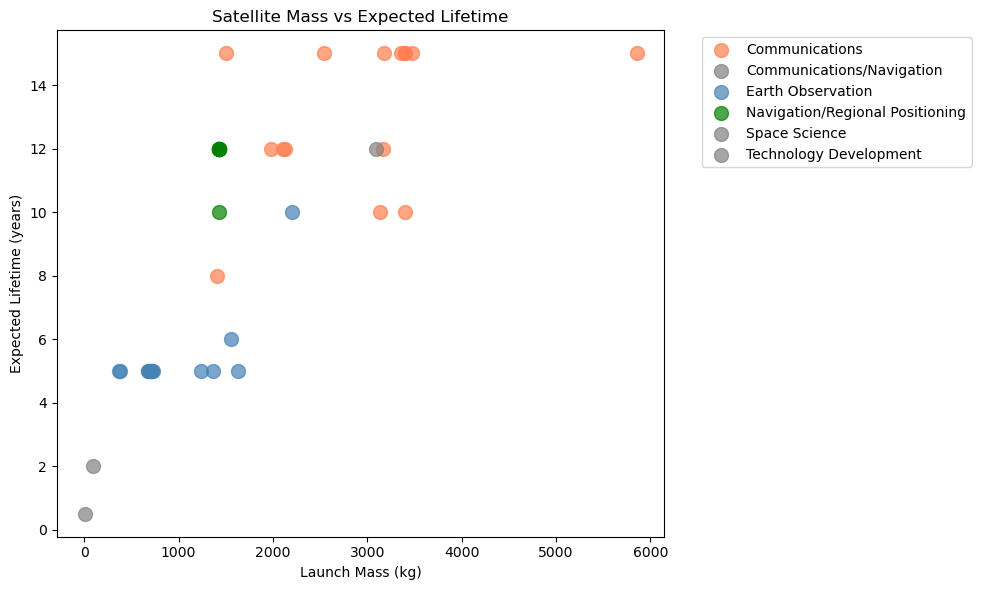

In [13]:
# Do heavier satellites last longer?
df['Expected Lifetime (yrs.)'] = pd.to_numeric(df['Expected Lifetime (yrs.)'], errors='coerce')

plt.figure(figsize=(10,6))
colors = {'Earth Observation':'steelblue', 'Communications':'coral', 
          'Navigation/Regional Positioning':'green'}

for purpose, group in df.groupby('Purpose'):
    color = colors.get(purpose, 'gray')
    plt.scatter(group['Launch Mass (kg.)'], 
                group['Expected Lifetime (yrs.)'],
                label=purpose, color=color, alpha=0.7, s=100)

plt.title('Satellite Mass vs Expected Lifetime')
plt.xlabel('Launch Mass (kg)')
plt.ylabel('Expected Lifetime (years)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()